# Notebook 06 — SHAP & LIME Explainability
## FYP: Adaptive Explainable Ensemble for Pre-Launch Steam Game Reception Prediction
### Heshan Ratnaweera | IIT Sri Lanka | W2082289 | 2026

**Purpose:** Generate dual explainability for all five specialist models using
SHAP (global feature importance) and LIME (local per-game explanations).

**Inputs:**
- `data/processed/games_features_t4.csv`
- `data/processed/sbert_embeddings_pca50.npy`
- `models/model_a.pkl` through `model_e.pkl`
- `models/pca_transformer.pkl`

**Outputs:** `outputs/figures/06_*.png` (SHAP + LIME charts)

---
## Contents
1. Setup & Imports
2. Load Models & Data
3. Reconstruct Feature Matrices Per Tier
4. SHAP — Model A (T1 Core)
5. SHAP — Model B (T2 Monetisation)
6. SHAP — Model C (T3 Community Labels)
7. SHAP — Model D (T4 Full Structured)
8. SHAP — Model E (T5 SBERT Fusion)
9. SHAP Cross-Tier Comparison
10. LIME — Local Explanations for Individual Games
11. Summary


## 1. Setup & Imports

In [7]:
import sys
import warnings
import joblib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── SHAP ──────────────────────────────────────────────────────────────────────
try:
    import shap
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

# ── LIME ──────────────────────────────────────────────────────────────────────
# lime does not expose __version__ — just confirm it imports cleanly
try:
    import lime
    import lime.lime_tabular
    print('LIME imported OK')
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime', '-q'])
    import lime
    import lime.lime_tabular
    print('LIME installed and imported OK')

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, make_scorer

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# ── Project root ───────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FEATURES_T4_CSV, MODELS_DIR, FIGURES_DIR, RESULTS_DIR,
    TARGET_COL, RANDOM_STATE, TEST_SIZE,
    TIER1_FEATURES, TIER2_FEATURES,
    TOP_20_TAGS, KEY_CATEGORIES
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

shap.initjs()
print('All imports OK')
print(f'Project root : {PROJECT_ROOT}')


SHAP version: 0.52.0
LIME imported OK


All imports OK
Project root : C:\Users\3214h\Documents\fyp-steam-reception


## 2. Load Models & Data

In [8]:
# ── Load all five specialist models ───────────────────────────────────────────
model_paths = {
    'A': MODELS_DIR / 'model_a.pkl',
    'B': MODELS_DIR / 'model_b.pkl',
    'C': MODELS_DIR / 'model_c.pkl',
    'D': MODELS_DIR / 'model_d.pkl',
    'E': MODELS_DIR / 'model_e.pkl',
}

models = {}
for name, path in model_paths.items():
    assert path.exists(), f'Model {name} not found at {path}. Run notebooks 04 and 05 first.'
    models[name] = joblib.load(path)
    print(f'Loaded Model {name}: {path.name}')

# ── Load PCA transformer ────────────────────────────────────────────────────────
pca_path = MODELS_DIR / 'pca_transformer.pkl'
assert pca_path.exists(), f'PCA transformer not found at {pca_path}.'
pca = joblib.load(pca_path)
PCA_COMPONENTS = pca.n_components_
print(f'\nLoaded PCA transformer: {PCA_COMPONENTS} components')

# ── Load feature matrix ────────────────────────────────────────────────────────
df = pd.read_csv(FEATURES_T4_CSV)
print(f'\nLoaded feature matrix: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Load SBERT embeddings (PCA-reduced) ───────────────────────────────────────
sbert_pca_path = PROJECT_ROOT / 'data' / 'processed' / f'sbert_embeddings_pca{PCA_COMPONENTS}.npy'
assert sbert_pca_path.exists(), f'SBERT embeddings not found at {sbert_pca_path}.'
embeddings_pca = np.load(sbert_pca_path)
print(f'Loaded SBERT PCA embeddings: {embeddings_pca.shape}')


Loaded Model A: model_a.pkl
Loaded Model B: model_b.pkl
Loaded Model C: model_c.pkl
Loaded Model D: model_d.pkl
Loaded Model E: model_e.pkl

Loaded PCA transformer: 50 components

Loaded feature matrix: 20,383 rows × 56 columns
Loaded SBERT PCA embeddings: (20383, 50)


## 3. Reconstruct Feature Matrices Per Tier

Reconstruct the same train-test split and per-tier feature matrices as notebooks 04 and 05.
Must use identical `RANDOM_STATE` and `TEST_SIZE` for valid comparison.


In [9]:
# ── Same split as all previous notebooks ──────────────────────────────────────
y           = df[TARGET_COL].values
all_indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

y_train = y[train_idx]
y_test  = y[test_idx]

# ── Define tier feature sets (matching notebook 04) ───────────────────────────
EXCLUDE_COLS = [TARGET_COL, 'short_description', 'dlc_count']
ALL_T4_FEATURES = [c for c in df.columns if c not in EXCLUDE_COLS]

tag_cols = [f'tag_{t.replace(" ","_").replace("-","_")}' for t in TOP_20_TAGS]
cat_cols = [f'cat_{c.replace(" ","_").replace("-","_").replace("/","_")}'
            for c in KEY_CATEGORIES]
EFFORT_SIGNALS = ['platform_coverage', 'has_achievements', 'has_website',
                  'supported_languages_count', 'screenshot_count', 'movie_count']

TIER_FEATURES = {
    'A': TIER1_FEATURES,
    'B': TIER2_FEATURES,
    'C': TIER2_FEATURES + tag_cols + cat_cols,
    'D': ALL_T4_FEATURES,
}

# ── Build per-model test matrices ──────────────────────────────────────────────
X_test = {}
X_train = {}
feature_names = {}

for model_name, features in TIER_FEATURES.items():
    X_test[model_name]  = df.iloc[test_idx][features].values
    X_train[model_name] = df.iloc[train_idx][features].values
    feature_names[model_name] = features

# Model E: T4 structured + SBERT PCA dims
text_dim_names = [f'text_dim_{i}' for i in range(PCA_COMPONENTS)]
emb_train = embeddings_pca[train_idx]
emb_test  = embeddings_pca[test_idx]

X_test['E']  = np.hstack([df.iloc[test_idx][ALL_T4_FEATURES].values,  emb_test])
X_train['E'] = np.hstack([df.iloc[train_idx][ALL_T4_FEATURES].values, emb_train])
feature_names['E'] = ALL_T4_FEATURES + text_dim_names

print('Feature matrices reconstructed:')
for m in ['A', 'B', 'C', 'D', 'E']:
    print(f'  Model {m}: train={X_train[m].shape}  test={X_test[m].shape}')


Feature matrices reconstructed:
  Model A: train=(16306, 13)  test=(4077, 13)
  Model B: train=(16306, 15)  test=(4077, 15)
  Model C: train=(16306, 47)  test=(4077, 47)
  Model D: train=(16306, 53)  test=(4077, 53)
  Model E: train=(16306, 103)  test=(4077, 103)


## 4–8. SHAP Analysis — All Five Models

In [10]:
# ── SHAP helper: compute and plot for one model ───────────────────────────────
# We use a background sample of 200 training games for the SHAP explainer.
# A background sample is needed for TreeExplainer to compute expected values.

SHAP_BACKGROUND = 200   # number of training games used as background
SHAP_EXPLAIN    = 500   # number of test games to compute SHAP values for
TOP_N_FEATURES  = 15    # show top N features in bar chart

np.random.seed(RANDOM_STATE)
shap_results = {}   # stores shap_values and explainer per model

print('Computing SHAP values for all models...')
print(f'Background sample: {SHAP_BACKGROUND} training games')
print(f'Explained games  : {SHAP_EXPLAIN} test games')
print()

for model_name in ['A', 'B', 'C', 'D', 'E']:
    print(f'Model {model_name} ({X_test[model_name].shape[1]} features)...', end=' ')

    # Sample background and explanation sets
    bg_idx  = np.random.choice(len(X_train[model_name]), SHAP_BACKGROUND, replace=False)
    exp_idx = np.random.choice(len(X_test[model_name]),  SHAP_EXPLAIN,    replace=False)

    X_bg  = X_train[model_name][bg_idx]
    X_exp = X_test[model_name][exp_idx]

    # TreeExplainer for CatBoost — fast and exact for tree models
    explainer   = shap.TreeExplainer(models[model_name], data=X_bg)
    shap_values = explainer.shap_values(X_exp)

    # shap_values may be a list [class0, class1] for binary classification
    # We use class 1 (Well Received) SHAP values
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    shap_results[model_name] = {
        'explainer':   explainer,
        'shap_values': sv,
        'X_exp':       X_exp,
        'y_exp':       y_test[exp_idx],
    }
    print(f'done. SHAP values shape: {sv.shape}')

print('\nAll SHAP values computed.')


Computing SHAP values for all models...
Background sample: 200 training games
Explained games  : 500 test games

Model A (13 features)... 

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


done. SHAP values shape: (500, 13)
Model B (15 features)... 

 93%|=================== | 467/500 [00:11<00:00]       Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


done. SHAP values shape: (500, 15)
Model C (47 features)... 

 97%|=================== | 485/500 [00:13<00:00]       Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


done. SHAP values shape: (500, 47)
Model D (53 features)... 

 94%|=================== | 471/500 [00:13<00:00]       Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


done. SHAP values shape: (500, 53)
Model E (103 features)... 

 95%|=================== | 475/500 [00:13<00:00]       

done. SHAP values shape: (500, 103)

All SHAP values computed.


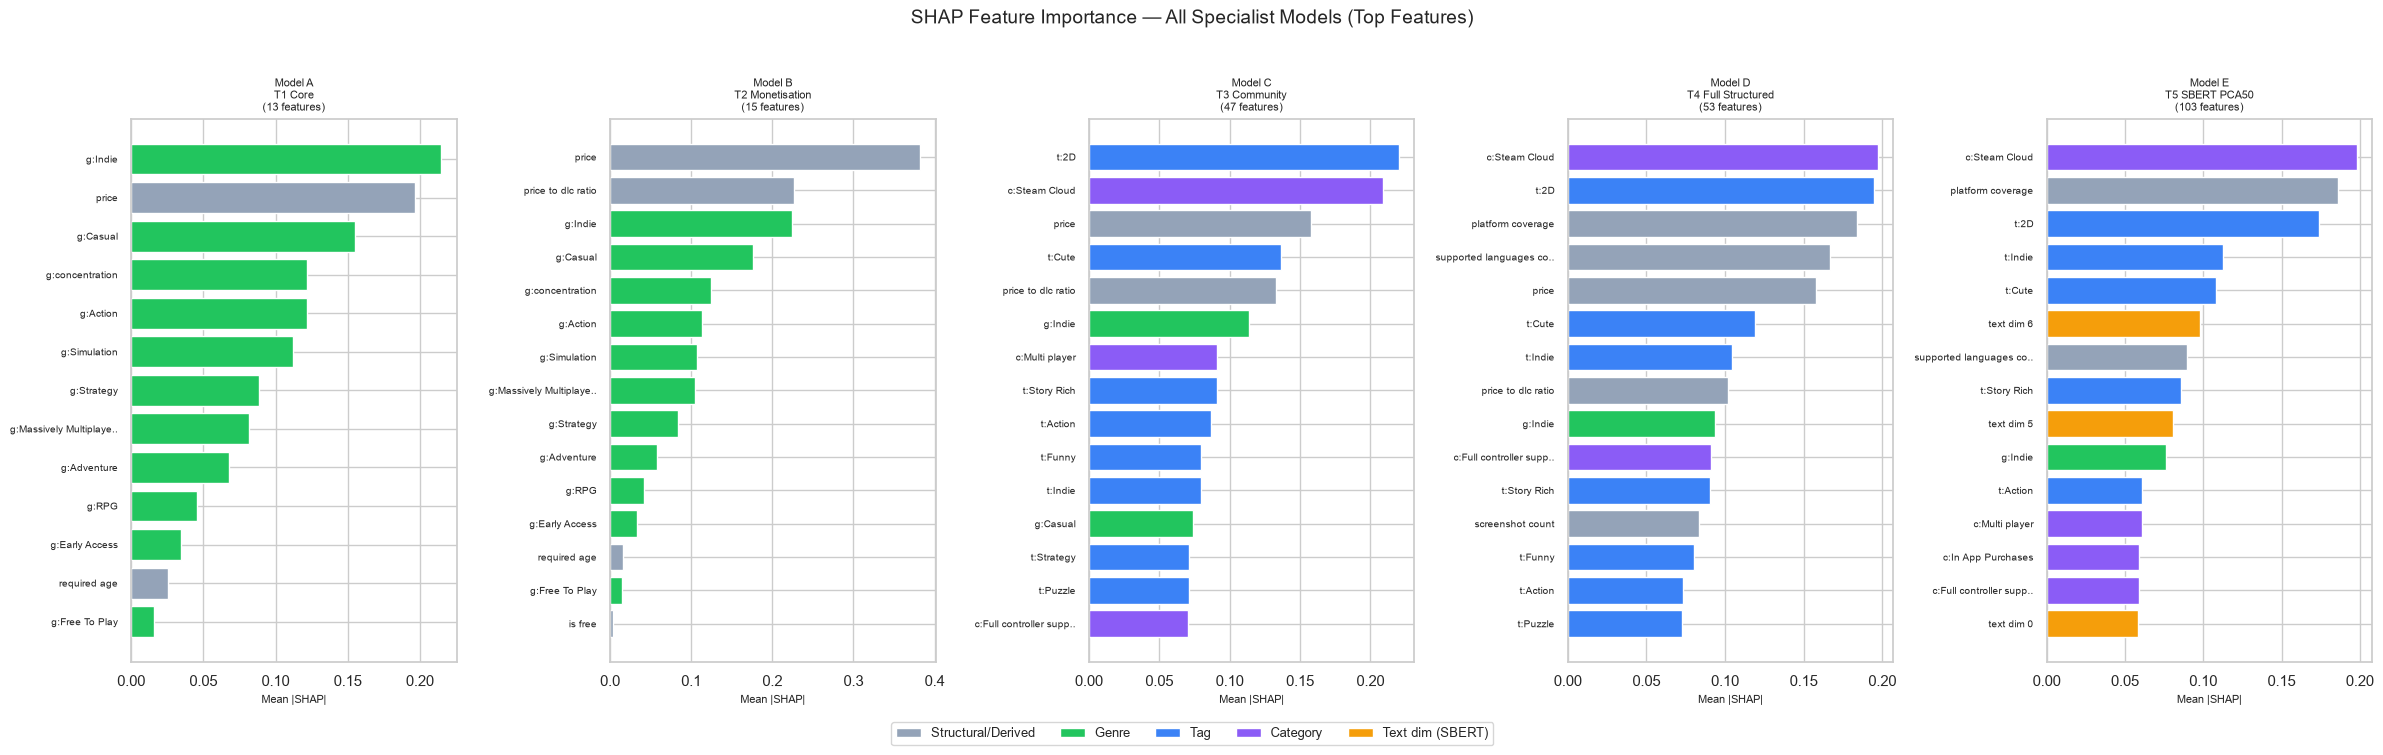

Saved: 06_shap_all_models.png


In [11]:
# ── Plot SHAP bar charts for all five models ──────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
fig.suptitle('SHAP Feature Importance — All Specialist Models (Top Features)',
             fontsize=14, y=1.02)

model_labels = {
    'A': 'Model A\nT1 Core\n(13 features)',
    'B': 'Model B\nT2 Monetisation\n(15 features)',
    'C': 'Model C\nT3 Community\n(47 features)',
    'D': 'Model D\nT4 Full Structured\n(53 features)',
    'E': f'Model E\nT5 SBERT PCA{PCA_COMPONENTS}\n({X_test["E"].shape[1]} features)',
}

for ax, model_name in zip(axes, ['A', 'B', 'C', 'D', 'E']):
    sv   = shap_results[model_name]['shap_values']
    fns  = feature_names[model_name]

    # Mean absolute SHAP value per feature
    mean_abs_shap = np.abs(sv).mean(axis=0)

    # Clip to actual number of features — avoids shape mismatch when
    # model has fewer features than TOP_N_FEATURES (e.g. Model A has 13)
    n_show   = min(TOP_N_FEATURES, len(fns))
    top_idx  = np.argsort(mean_abs_shap)[-n_show:][::-1]

    top_features = [fns[i] for i in top_idx]
    top_shap     = mean_abs_shap[top_idx]

    # Colour by feature type
    colors = []
    for f in top_features:
        if f.startswith('text_dim'):
            colors.append('#f59e0b')   # orange — SBERT text dimension
        elif f.startswith('genre_'):
            colors.append('#22c55e')   # green — genre one-hot
        elif f.startswith('tag_'):
            colors.append('#3b82f6')   # blue — tag one-hot
        elif f.startswith('cat_'):
            colors.append('#8b5cf6')   # purple — category one-hot
        else:
            colors.append('#94a3b8')   # gray — structural / derived

    # Shorten names for display
    short_names = []
    for f in top_features:
        f = f.replace('genre_', 'g:').replace('tag_', 't:').replace('cat_', 'c:')
        f = f.replace('_', ' ')
        short_names.append(f[:22] + '..' if len(f) > 22 else f)

    # Use len(top_shap) not TOP_N_FEATURES — they differ for small models
    ax.barh(range(len(top_shap)), top_shap[::-1], color=colors[::-1])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(short_names[::-1], fontsize=7)
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    ax.set_title(model_labels[model_name], fontsize=8)

# Colour legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#94a3b8', label='Structural/Derived'),
    Patch(facecolor='#22c55e', label='Genre'),
    Patch(facecolor='#3b82f6', label='Tag'),
    Patch(facecolor='#8b5cf6', label='Category'),
    Patch(facecolor='#f59e0b', label='Text dim (SBERT)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '06_shap_all_models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_shap_all_models.png')


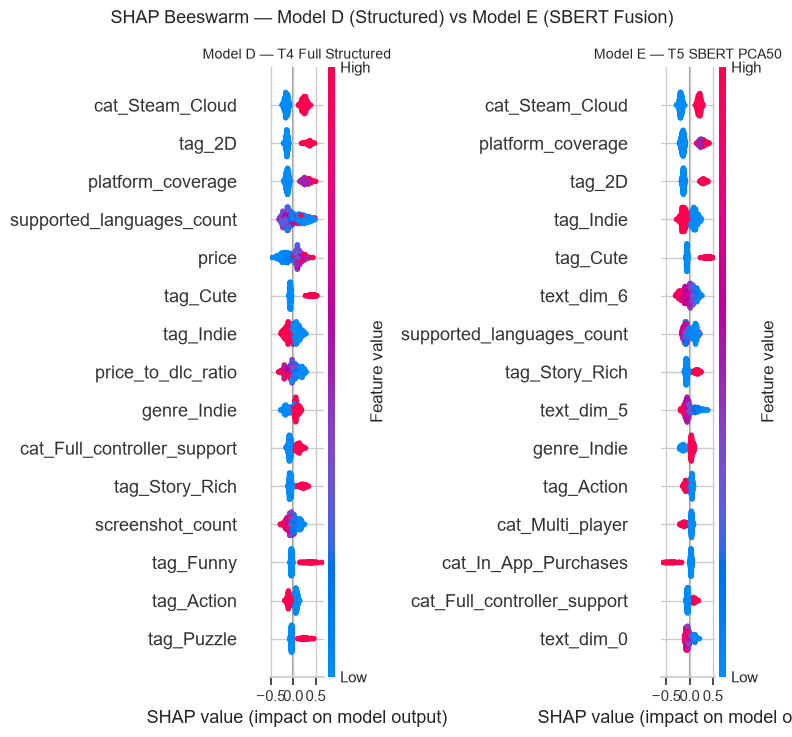

Saved: 06_shap_beeswarm_d_e.png


In [12]:
# ── Individual SHAP beeswarm plots for Model D and E ─────────────────────────
# Beeswarm shows direction of impact — positive SHAP pushes toward Well Received,
# negative SHAP pushes toward Not Well Received

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('SHAP Beeswarm — Model D (Structured) vs Model E (SBERT Fusion)',
             fontsize=13)

for ax, model_name, title in [
    (axes[0], 'D', 'Model D — T4 Full Structured'),
    (axes[1], 'E', f'Model E — T5 SBERT PCA{PCA_COMPONENTS}'),
]:
    sv   = shap_results[model_name]['shap_values']
    X_e  = shap_results[model_name]['X_exp']
    fns  = feature_names[model_name]

    plt.sca(ax)
    shap.summary_plot(
        sv, X_e,
        feature_names=fns,
        max_display=15,
        show=False,
        plot_type='dot'
    )
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '06_shap_beeswarm_d_e.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_shap_beeswarm_d_e.png')


## 9. SHAP Cross-Tier Comparison

Track how the importance of shared features changes as we move from T1 to T4.
This shows which features consistently matter across all tiers and which become
important only at higher tiers.


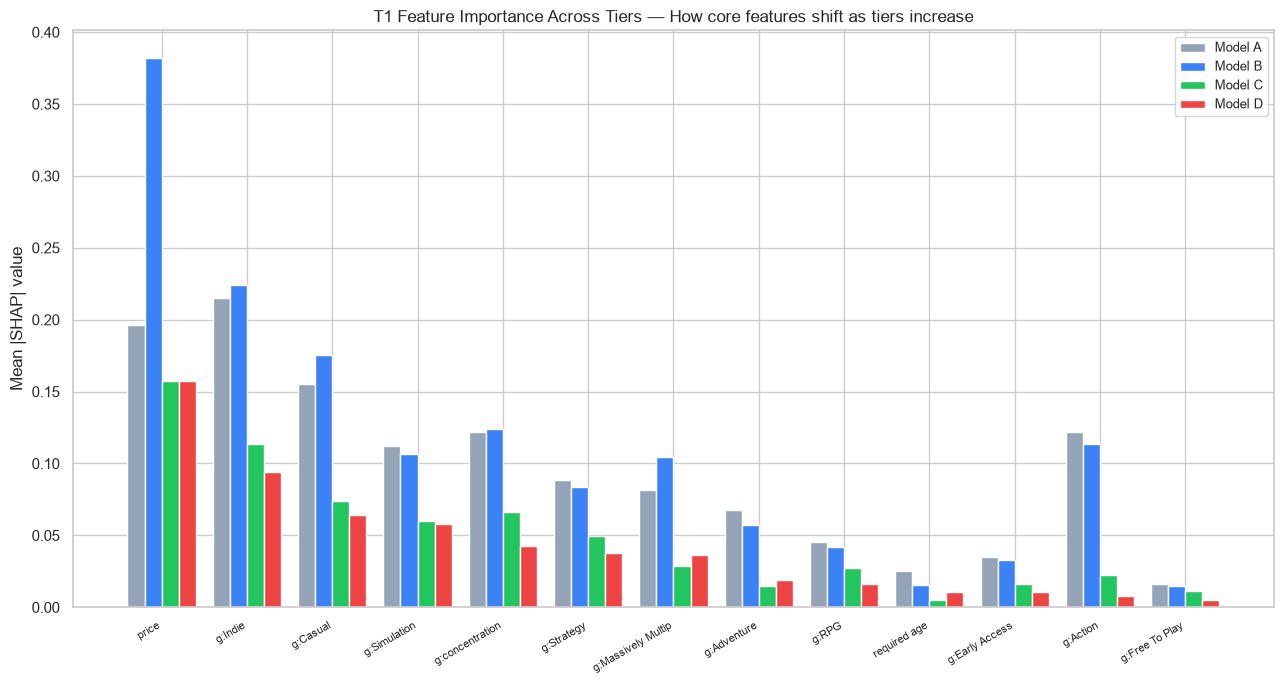

Saved: 06_shap_cross_tier.png

=== TOP 5 FEATURES BY MODEL (mean |SHAP|) ===

  Model A:
    1. genre_Indie                              0.2148
    2. price                                    0.1965
    3. genre_Casual                             0.1554
    4. genre_concentration                      0.1218
    5. genre_Action                             0.1218

  Model B:
    1. price                                    0.3820
    2. price_to_dlc_ratio                       0.2262
    3. genre_Indie                              0.2239
    4. genre_Casual                             0.1757
    5. genre_concentration                      0.1240

  Model C:
    1. tag_2D                                   0.2202
    2. cat_Steam_Cloud                          0.2090
    3. price                                    0.1576
    4. tag_Cute                                 0.1364
    5. price_to_dlc_ratio                       0.1331

  Model D:
    1. cat_Steam_Cloud                          0.

In [13]:
# ── Track importance of T1 shared features across all tiers ──────────────────
# T1 features (price, required_age, genre one-hots, genre_concentration)
# appear in all four structured models — we track how their importance
# changes as more features are added at higher tiers

shared_features = TIER_FEATURES['A']   # T1 features present in all models

shared_importance = {}
for model_name in ['A', 'B', 'C', 'D']:
    sv  = shap_results[model_name]['shap_values']
    fns = feature_names[model_name]
    mean_abs = np.abs(sv).mean(axis=0)

    for feat in shared_features:
        if feat in fns:
            idx = fns.index(feat)
            if feat not in shared_importance:
                shared_importance[feat] = {}
            shared_importance[feat][f'Model {model_name}'] = mean_abs[idx]

shared_df = pd.DataFrame(shared_importance).T.fillna(0)
shared_df = shared_df.sort_values('Model D', ascending=False).head(13)

fig, ax = plt.subplots(figsize=(13, 7))
x      = np.arange(len(shared_df))
width  = 0.2
colors = ['#94a3b8', '#3b82f6', '#22c55e', '#ef4444']

for i, (col, color) in enumerate(zip(shared_df.columns, colors)):
    ax.bar(x + i * width, shared_df[col], width, label=col,
           color=color, edgecolor='white')

short_labels = []
for f in shared_df.index:
    f2 = f.replace('genre_', 'g:').replace('_', ' ')
    short_labels.append(f2[:18])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Mean |SHAP| value')
ax.set_title('T1 Feature Importance Across Tiers — How core features shift as tiers increase')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '06_shap_cross_tier.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_shap_cross_tier.png')

# ── Print top 5 features per model ────────────────────────────────────────────
print()
print('=== TOP 5 FEATURES BY MODEL (mean |SHAP|) ===')
for model_name in ['A', 'B', 'C', 'D', 'E']:
    sv       = shap_results[model_name]['shap_values']
    fns      = feature_names[model_name]
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[-5:][::-1]
    print(f'\n  Model {model_name}:')
    for rank, idx in enumerate(top_idx, 1):
        print(f'    {rank}. {fns[idx]:<40} {mean_abs[idx]:.4f}')


## 10. LIME — Local Per-Game Explanations

LIME (Local Interpretable Model-agnostic Explanations) explains individual
predictions by fitting a simple linear model around a single game's feature values.

We select 6 representative test games:
- 2 games correctly predicted as Well Received
- 2 games correctly predicted as Not Well Received
- 2 games where the model was wrong (misclassifications)

This gives developers a concrete sense of which features drove the prediction
for their specific game.


In [14]:
# ── Set up LIME explainer for Model D (T4 full structured) ───────────────────
# We use Model D rather than E for LIME because:
# 1. Model D's 53 features are all interpretable (named features)
# 2. Model E's text_dim_0–49 are not interpretable without mapping back to words
# LIME for Model E's text component is handled separately using description text

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train['D'],
    feature_names=feature_names['D'],
    class_names=['Not Well Received', 'Well Received'],
    mode='classification',
    random_state=RANDOM_STATE,
    discretize_continuous=True    # converts continuous features to ranges for readability
)

# ── Select 6 representative games ─────────────────────────────────────────────
y_pred_d = models['D'].predict(X_test['D'])

# Find examples in each category
correct_pos  = np.where((y_test == 1) & (y_pred_d == 1))[0][:2]   # correctly Well Received
correct_neg  = np.where((y_test == 0) & (y_pred_d == 0))[0][:2]   # correctly Not Well Received
wrong_pos    = np.where((y_test == 0) & (y_pred_d == 1))[0][:1]   # false positive
wrong_neg    = np.where((y_test == 1) & (y_pred_d == 0))[0][:1]   # false negative

sample_indices = list(correct_pos) + list(correct_neg) + list(wrong_pos) + list(wrong_neg)
sample_labels  = (
    ['Correct: Well Received'] * len(correct_pos) +
    ['Correct: Not Well Received'] * len(correct_neg) +
    ['Wrong: predicted Well Received'] * len(wrong_pos) +
    ['Wrong: predicted Not Well Received'] * len(wrong_neg)
)

print(f'Selected {len(sample_indices)} sample games for LIME explanation:')
for i, (idx, label) in enumerate(zip(sample_indices, sample_labels)):
    prob = models['D'].predict_proba(X_test['D'][idx:idx+1])[0]
    actual = 'Well Received' if y_test[idx] == 1 else 'Not Well Received'
    print(f'  Game {i+1}: {label}')
    print(f'    Actual={actual}  predict_proba=[{prob[0]:.3f}, {prob[1]:.3f}]')


Selected 6 sample games for LIME explanation:
  Game 1: Correct: Well Received
    Actual=Well Received  predict_proba=[0.329, 0.671]
  Game 2: Correct: Well Received
    Actual=Well Received  predict_proba=[0.334, 0.666]
  Game 3: Correct: Not Well Received
    Actual=Not Well Received  predict_proba=[0.648, 0.352]
  Game 4: Correct: Not Well Received
    Actual=Not Well Received  predict_proba=[0.637, 0.363]
  Game 5: Wrong: predicted Well Received
    Actual=Not Well Received  predict_proba=[0.395, 0.605]
  Game 6: Wrong: predicted Not Well Received
    Actual=Well Received  predict_proba=[0.679, 0.321]


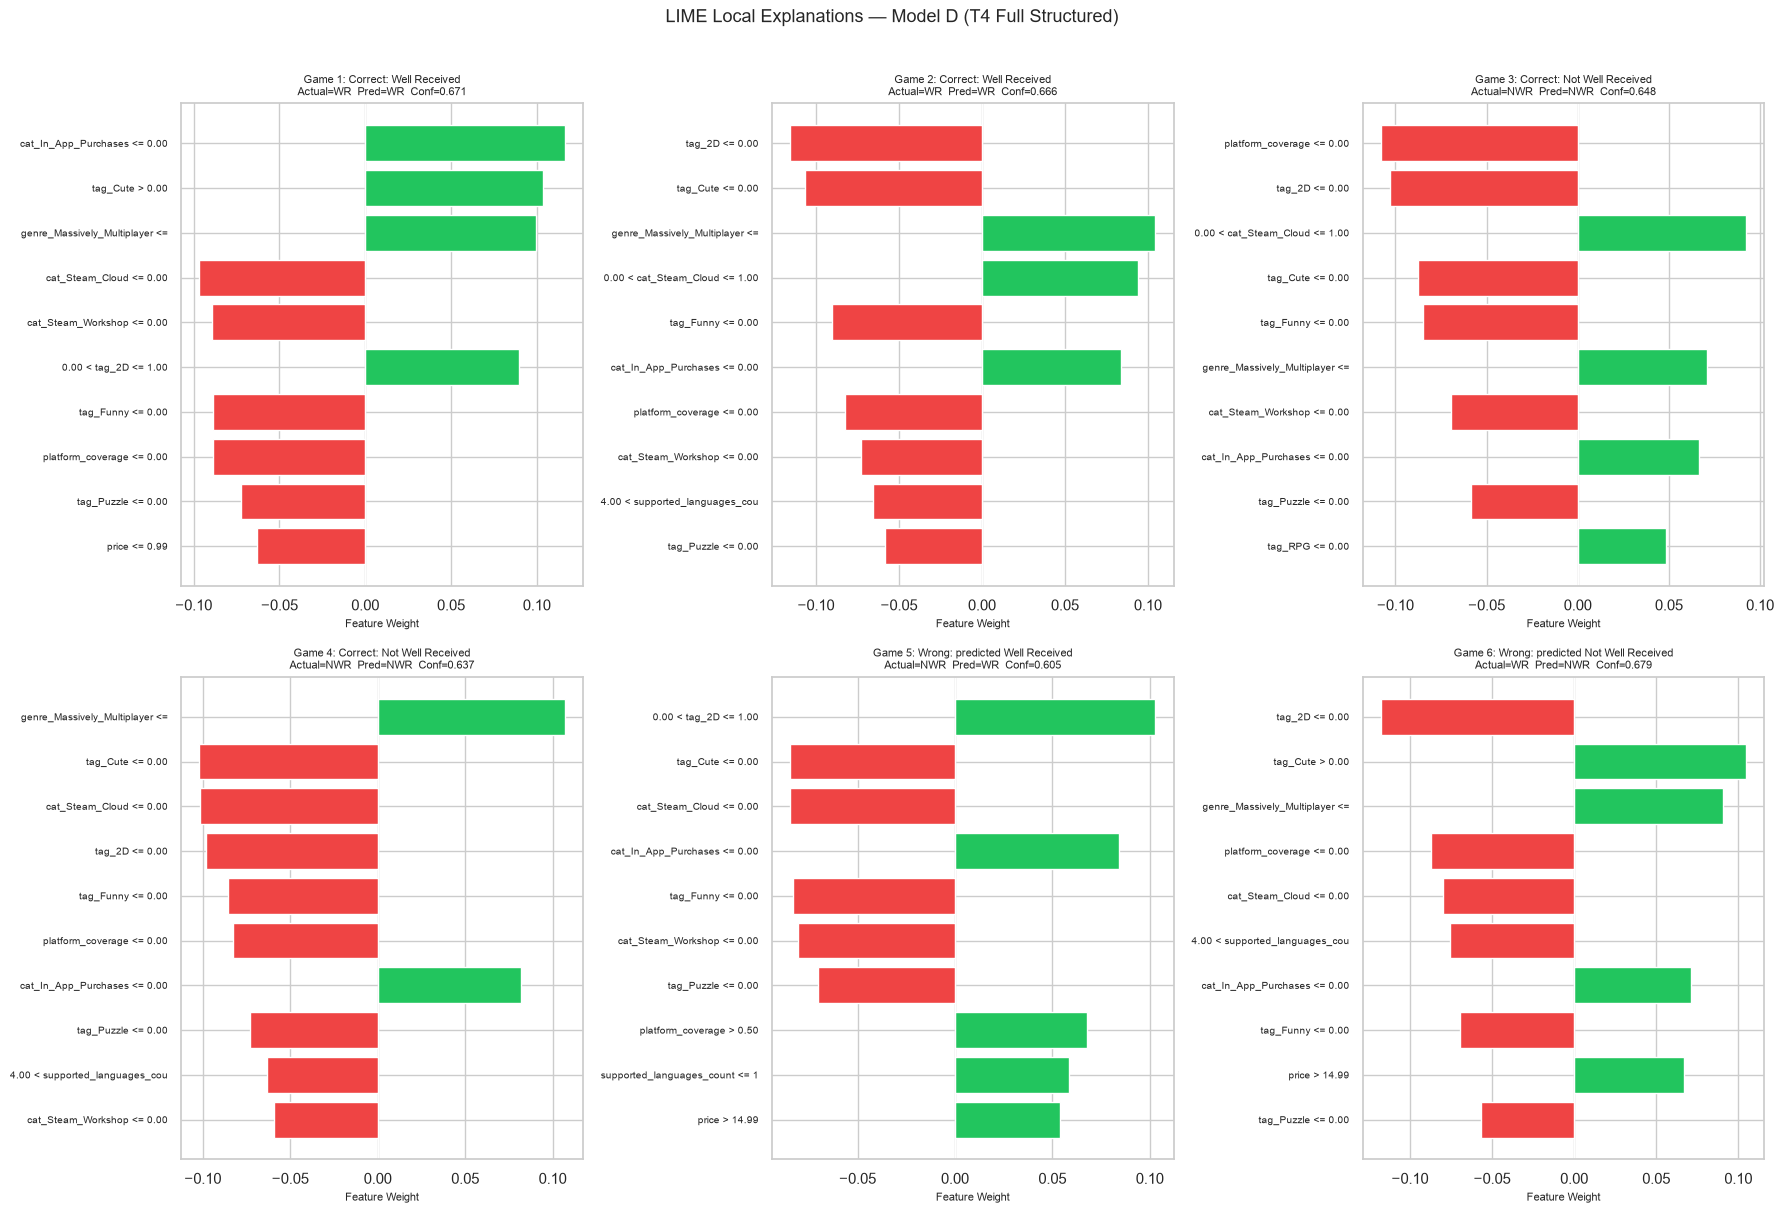

Saved: 06_lime_model_d.png


In [15]:
# ── Generate LIME explanations and plot ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('LIME Local Explanations — Model D (T4 Full Structured)',
             fontsize=13, y=1.01)
axes = axes.flatten()

lime_explanations = []

for plot_i, (sample_idx, label) in enumerate(zip(sample_indices, sample_labels)):
    exp = lime_explainer.explain_instance(
        data_row=X_test['D'][sample_idx],
        predict_fn=models['D'].predict_proba,
        num_features=10,
        num_samples=1000
    )
    lime_explanations.append(exp)

    exp_list      = exp.as_list()
    features_lime = [e[0] for e in exp_list]
    weights_lime  = [e[1] for e in exp_list]

    ax     = axes[plot_i]
    colors = ['#22c55e' if w > 0 else '#ef4444' for w in weights_lime]
    ax.barh(range(len(weights_lime)), weights_lime[::-1], color=colors[::-1])
    ax.set_yticks(range(len(features_lime)))
    ax.set_yticklabels([f[:30] for f in features_lime[::-1]], fontsize=7)
    ax.axvline(0, color='white', linewidth=0.8)
    ax.set_xlabel('Feature Weight', fontsize=8)

    prob   = models['D'].predict_proba(X_test['D'][sample_idx:sample_idx+1])[0]
    actual = 'WR' if y_test[sample_idx] == 1 else 'NWR'
    pred   = 'WR' if y_pred_d[sample_idx] == 1 else 'NWR'
    ax.set_title(f'Game {plot_i+1}: {label}\nActual={actual}  Pred={pred}  '
                 f'Conf={max(prob):.3f}', fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '06_lime_model_d.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_lime_model_d.png')


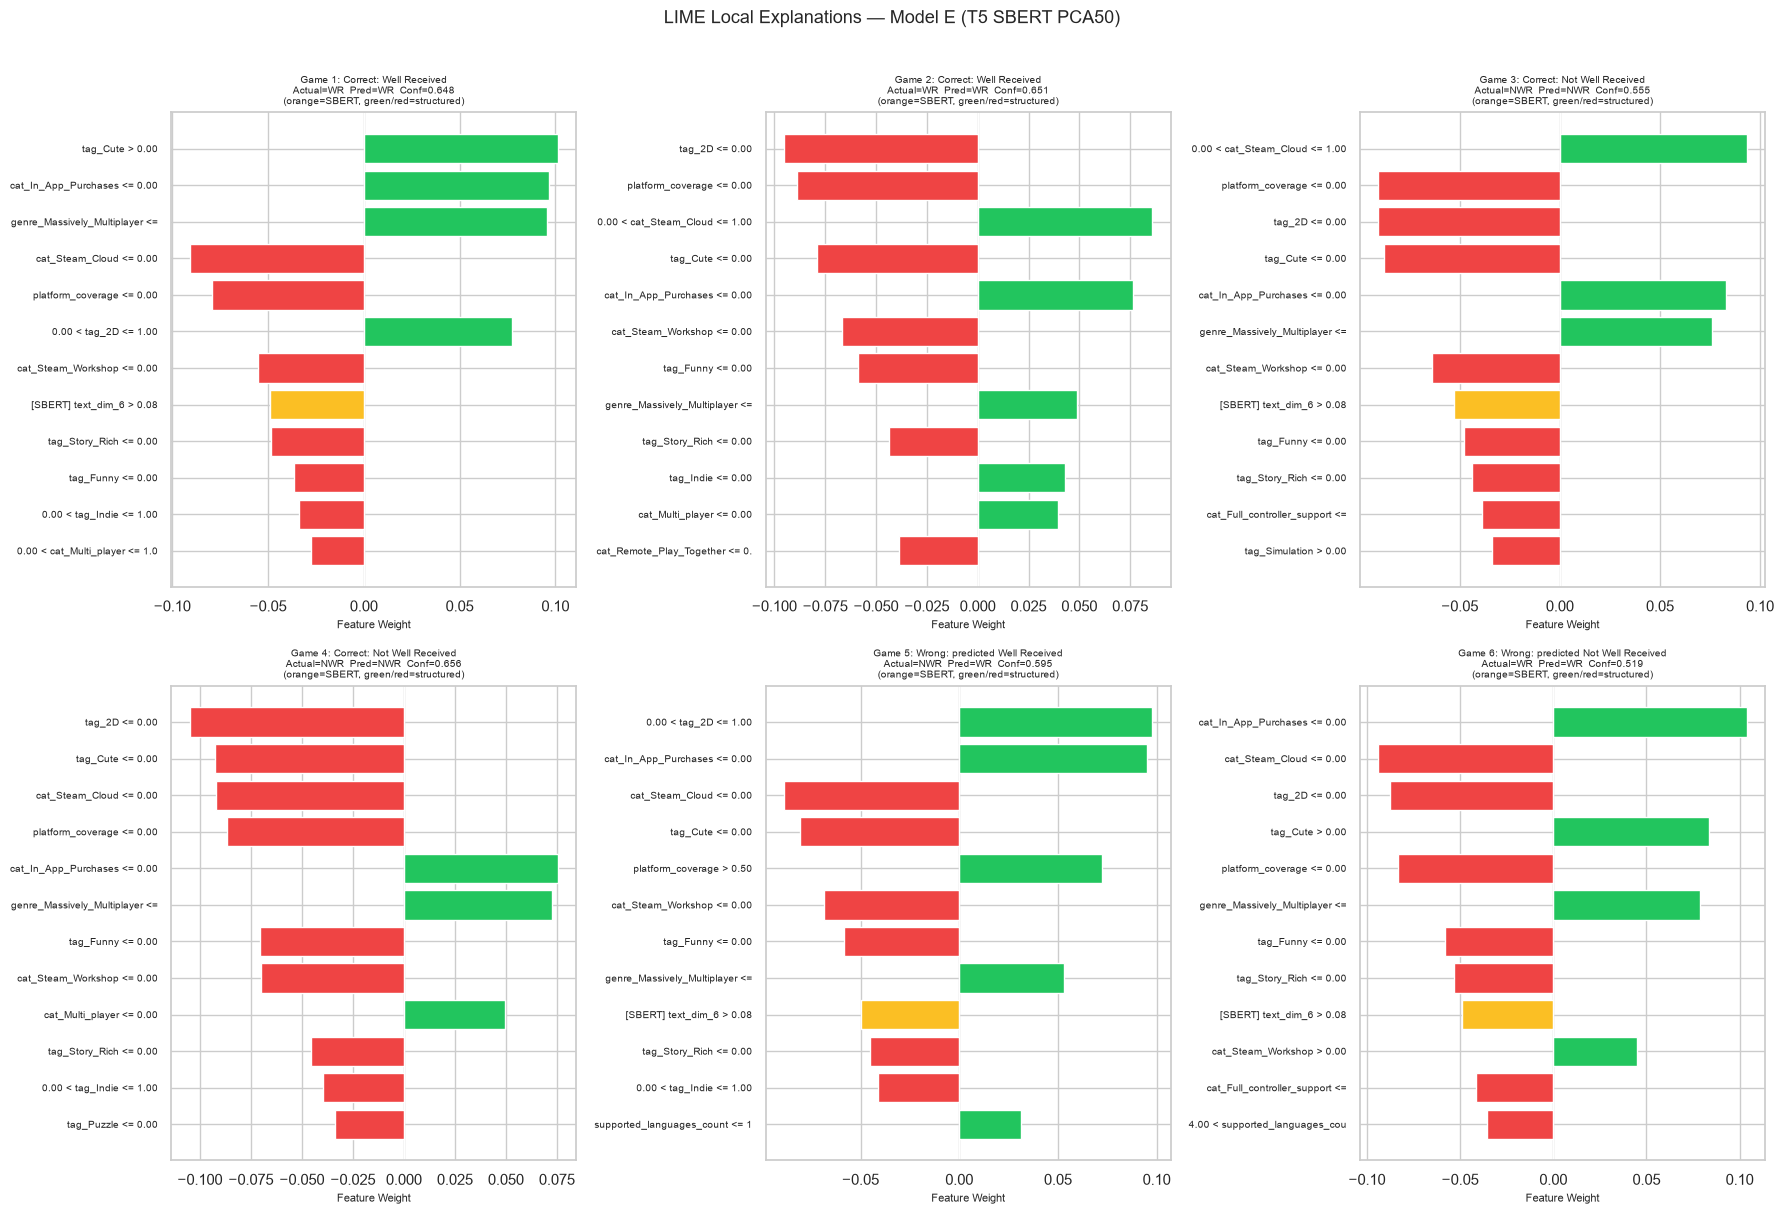

Saved: 06_lime_model_e.png

=== TEXT vs STRUCTURED CONTRIBUTION IN MODEL E (LIME) ===
  Game         Structured   SBERT Text
  ------------------------------------
  Game 1           -0.0013      -0.0488
  Game 2           -0.1781       0.0000
  Game 3           -0.2446      -0.0529
  Game 4           -0.4383       0.0000
  Game 5           -0.0340      -0.0495
  Game 6           -0.1421      -0.0493


In [16]:
# ── LIME for Model E — structured vs SBERT text contribution ─────────────────
lime_explainer_e = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train['E'],
    feature_names=feature_names['E'],
    class_names=['Not Well Received', 'Well Received'],
    mode='classification',
    random_state=RANDOM_STATE,
    discretize_continuous=True
)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'LIME Local Explanations — Model E (T5 SBERT PCA{PCA_COMPONENTS})',
             fontsize=13, y=1.01)
axes = axes.flatten()

text_dim_contribution = []

for plot_i, (sample_idx, label) in enumerate(zip(sample_indices, sample_labels)):
    exp = lime_explainer_e.explain_instance(
        data_row=X_test['E'][sample_idx],
        predict_fn=models['E'].predict_proba,
        num_features=12,
        num_samples=1000
    )

    exp_list      = exp.as_list()
    features_lime = [e[0] for e in exp_list]
    weights_lime  = [e[1] for e in exp_list]

    text_weight   = sum(w for f, w in exp_list if 'text_dim' in f)
    struct_weight = sum(w for f, w in exp_list if 'text_dim' not in f)
    text_dim_contribution.append({
        'game': plot_i + 1,
        'text_contribution':   text_weight,
        'struct_contribution': struct_weight,
    })

    ax     = axes[plot_i]
    colors = []
    for f, w in zip(features_lime, weights_lime):
        if 'text_dim' in f:
            colors.append('#f59e0b' if w > 0 else '#fbbf24')
        else:
            colors.append('#22c55e' if w > 0 else '#ef4444')

    ax.barh(range(len(weights_lime)), weights_lime[::-1], color=colors[::-1])
    ax.set_yticks(range(len(features_lime)))

    display_labels = []
    for f in features_lime[::-1]:
        if 'text_dim' in f:
            display_labels.append(f'[SBERT] {f}')
        else:
            display_labels.append(f[:30])
    ax.set_yticklabels(display_labels, fontsize=7)
    ax.axvline(0, color='white', linewidth=0.8)
    ax.set_xlabel('Feature Weight', fontsize=8)

    prob   = models['E'].predict_proba(X_test['E'][sample_idx:sample_idx+1])[0]
    actual = 'WR' if y_test[sample_idx] == 1 else 'NWR'
    pred_e = 'WR' if models['E'].predict(X_test['E'][sample_idx:sample_idx+1])[0] == 1 else 'NWR'
    ax.set_title(f'Game {plot_i+1}: {label}\nActual={actual}  Pred={pred_e}  '
                 f'Conf={max(prob):.3f}\n(orange=SBERT, green/red=structured)',
                 fontsize=7)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '06_lime_model_e.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_lime_model_e.png')

# ── Text vs structured contribution summary ────────────────────────────────────
print()
print('=== TEXT vs STRUCTURED CONTRIBUTION IN MODEL E (LIME) ===')
print(f'  {"Game":<8} {"Structured":>14} {"SBERT Text":>12}')
print('  ' + '-' * 36)
for row in text_dim_contribution:
    print(f'  Game {row["game"]:<4} {row["struct_contribution"]:>14.4f} '
          f'{row["text_contribution"]:>12.4f}')


## 11. Summary

In [17]:
print('=' * 65)
print('NOTEBOOK 06 — EXPLAINABILITY SUMMARY')
print('=' * 65)

print(f'\nSHAP ANALYSIS')
print(f'  Method          : TreeExplainer (exact for CatBoost)')
print(f'  Background      : {SHAP_BACKGROUND} training games')
print(f'  Games explained : {SHAP_EXPLAIN} test games per model')
print(f'  Models covered  : A, B, C, D, E')

print(f'\nTOP FEATURES BY MODEL:')
for model_name in ['A', 'B', 'C', 'D', 'E']:
    sv  = shap_results[model_name]['shap_values']
    fns = feature_names[model_name]
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[-3:][::-1]
    tops = ', '.join(fns[i] for i in top_idx)
    print(f'  Model {model_name}: {tops}')

print(f'\nLIME ANALYSIS')
print(f'  Method     : LimeTabularExplainer (discretize_continuous=True)')
print(f'  Games      : {len(sample_indices)} representative games')
print(f'               (2 correct WR, 2 correct NWR, 1 false pos, 1 false neg)')
print(f'  Models     : D (structured) and E (SBERT fusion)')

print(f'\nFIGURES SAVED TO: {FIGURES_DIR}')
figures = [
    '06_shap_all_models.png        — SHAP bar charts for all 5 models',
    '06_shap_beeswarm_d_e.png      — SHAP beeswarm: Model D vs Model E',
    '06_shap_cross_tier.png        — Shared feature importance across tiers',
    '06_lime_model_d.png           — LIME explanations for 6 games (Model D)',
    '06_lime_model_e.png           — LIME explanations for 6 games (Model E)',
]
for f in figures:
    print(f'  {f}')

print(f'\nNEXT STEP: Notebook 07 — Ablation Study')
print(f'  Load benchmark_table.csv, tier_ablation.csv, sbert_ablation.csv')
print(f'  Compile full 4-way ablation table')
print(f'  Document all findings for thesis results chapter')
print('=' * 65)


NOTEBOOK 06 — EXPLAINABILITY SUMMARY

SHAP ANALYSIS
  Method          : TreeExplainer (exact for CatBoost)
  Background      : 200 training games
  Games explained : 500 test games per model
  Models covered  : A, B, C, D, E

TOP FEATURES BY MODEL:
  Model A: genre_Indie, price, genre_Casual
  Model B: price, price_to_dlc_ratio, genre_Indie
  Model C: tag_2D, cat_Steam_Cloud, price
  Model D: cat_Steam_Cloud, tag_2D, platform_coverage
  Model E: cat_Steam_Cloud, platform_coverage, tag_2D

LIME ANALYSIS
  Method     : LimeTabularExplainer (discretize_continuous=True)
  Games      : 6 representative games
               (2 correct WR, 2 correct NWR, 1 false pos, 1 false neg)
  Models     : D (structured) and E (SBERT fusion)

FIGURES SAVED TO: C:\Users\3214h\Documents\fyp-steam-reception\outputs\figures
  06_shap_all_models.png        — SHAP bar charts for all 5 models
  06_shap_beeswarm_d_e.png      — SHAP beeswarm: Model D vs Model E
  06_shap_cross_tier.png        — Shared feature imp